REGRESSION


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,mean_absolute_percentage_error,root_mean_squared_error

In [2]:
hr=pd.read_csv(r"C:\Users\Inchara\Downloads\HR-Employee-Attrition-10000.csv")
hr

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,50,No,Travel_Rarely,270,Sales,9,3,Marketing,1,1642,...,3,80,1,27,2,3,1,0,0,0
1,30,No,Travel_Rarely,1381,Research & Development,13,2,Other,1,2022,...,1,80,1,10,2,3,4,3,0,3
2,22,Yes,Travel_Frequently,1275,Research & Development,2,4,Life Sciences,1,1234,...,2,80,1,1,5,3,0,0,0,0
3,41,No,Travel_Rarely,401,Research & Development,6,3,Life Sciences,1,1800,...,1,80,0,11,3,1,3,2,1,2
4,35,No,Travel_Rarely,736,Research & Development,28,3,Life Sciences,1,1564,...,4,80,2,10,3,2,10,9,6,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,30,Yes,Travel_Rarely,139,Research & Development,22,3,Life Sciences,1,1037,...,2,80,0,7,2,3,5,2,0,1
9996,31,No,Travel_Rarely,992,Sales,5,3,Technical Degree,1,1789,...,3,80,1,6,3,3,5,2,0,2
9997,26,Yes,Travel_Rarely,1342,Research & Development,25,3,Life Sciences,1,53,...,3,80,0,0,2,2,1,0,0,1
9998,45,No,Travel_Rarely,471,Sales,3,3,Technical Degree,1,337,...,2,80,1,28,2,2,7,7,7,7


INITIAL ANALYSIS

In [3]:
hr.shape

(10000, 35)

In [4]:
hr.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,50,No,Travel_Rarely,270,Sales,9,3,Marketing,1,1642,...,3,80,1,27,2,3,1,0,0,0
1,30,No,Travel_Rarely,1381,Research & Development,13,2,Other,1,2022,...,1,80,1,10,2,3,4,3,0,3
2,22,Yes,Travel_Frequently,1275,Research & Development,2,4,Life Sciences,1,1234,...,2,80,1,1,5,3,0,0,0,0
3,41,No,Travel_Rarely,401,Research & Development,6,3,Life Sciences,1,1800,...,1,80,0,11,3,1,3,2,1,2
4,35,No,Travel_Rarely,736,Research & Development,28,3,Life Sciences,1,1564,...,4,80,2,10,3,2,10,9,6,8


In [5]:
hr.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
9995,30,Yes,Travel_Rarely,139,Research & Development,22,3,Life Sciences,1,1037,...,2,80,0,7,2,3,5,2,0,1
9996,31,No,Travel_Rarely,992,Sales,5,3,Technical Degree,1,1789,...,3,80,1,6,3,3,5,2,0,2
9997,26,Yes,Travel_Rarely,1342,Research & Development,25,3,Life Sciences,1,53,...,3,80,0,0,2,2,1,0,0,1
9998,45,No,Travel_Rarely,471,Sales,3,3,Technical Degree,1,337,...,2,80,1,28,2,2,7,7,7,7
9999,33,No,Travel_Rarely,606,Sales,7,5,Marketing,1,1432,...,3,80,1,7,3,2,4,3,0,3


In [6]:
hr.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [7]:
hr.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
hr.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
hr.describe

<bound method NDFrame.describe of       Age Attrition     BusinessTravel  DailyRate              Department  \
0      50        No      Travel_Rarely        270                   Sales   
1      30        No      Travel_Rarely       1381  Research & Development   
2      22       Yes  Travel_Frequently       1275  Research & Development   
3      41        No      Travel_Rarely        401  Research & Development   
4      35        No      Travel_Rarely        736  Research & Development   
...   ...       ...                ...        ...                     ...   
9995   30       Yes      Travel_Rarely        139  Research & Development   
9996   31        No      Travel_Rarely        992                   Sales   
9997   26       Yes      Travel_Rarely       1342  Research & Development   
9998   45        No      Travel_Rarely        471                   Sales   
9999   33        No      Travel_Rarely        606                   Sales   

      DistanceFromHome  Education    Educ

In [10]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       10000 non-null  int64 
 1   Attrition                 10000 non-null  object
 2   BusinessTravel            10000 non-null  object
 3   DailyRate                 10000 non-null  int64 
 4   Department                10000 non-null  object
 5   DistanceFromHome          10000 non-null  int64 
 6   Education                 10000 non-null  int64 
 7   EducationField            10000 non-null  object
 8   EmployeeCount             10000 non-null  int64 
 9   EmployeeNumber            10000 non-null  int64 
 10  EnvironmentSatisfaction   10000 non-null  int64 
 11  Gender                    10000 non-null  object
 12  HourlyRate                10000 non-null  int64 
 13  JobInvolvement            10000 non-null  int64 
 14  JobLevel               

DATA CLEANING

In [11]:
hr.drop_duplicates()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,50,No,Travel_Rarely,270,Sales,9,3,Marketing,1,1642,...,3,80,1,27,2,3,1,0,0,0
1,30,No,Travel_Rarely,1381,Research & Development,13,2,Other,1,2022,...,1,80,1,10,2,3,4,3,0,3
2,22,Yes,Travel_Frequently,1275,Research & Development,2,4,Life Sciences,1,1234,...,2,80,1,1,5,3,0,0,0,0
3,41,No,Travel_Rarely,401,Research & Development,6,3,Life Sciences,1,1800,...,1,80,0,11,3,1,3,2,1,2
4,35,No,Travel_Rarely,736,Research & Development,28,3,Life Sciences,1,1564,...,4,80,2,10,3,2,10,9,6,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,30,Yes,Travel_Rarely,139,Research & Development,22,3,Life Sciences,1,1037,...,2,80,0,7,2,3,5,2,0,1
9996,31,No,Travel_Rarely,992,Sales,5,3,Technical Degree,1,1789,...,3,80,1,6,3,3,5,2,0,2
9997,26,Yes,Travel_Rarely,1342,Research & Development,25,3,Life Sciences,1,53,...,3,80,0,0,2,2,1,0,0,1
9998,45,No,Travel_Rarely,471,Sales,3,3,Technical Degree,1,337,...,2,80,1,28,2,2,7,7,7,7


In [12]:
hr.dropna()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,50,No,Travel_Rarely,270,Sales,9,3,Marketing,1,1642,...,3,80,1,27,2,3,1,0,0,0
1,30,No,Travel_Rarely,1381,Research & Development,13,2,Other,1,2022,...,1,80,1,10,2,3,4,3,0,3
2,22,Yes,Travel_Frequently,1275,Research & Development,2,4,Life Sciences,1,1234,...,2,80,1,1,5,3,0,0,0,0
3,41,No,Travel_Rarely,401,Research & Development,6,3,Life Sciences,1,1800,...,1,80,0,11,3,1,3,2,1,2
4,35,No,Travel_Rarely,736,Research & Development,28,3,Life Sciences,1,1564,...,4,80,2,10,3,2,10,9,6,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,30,Yes,Travel_Rarely,139,Research & Development,22,3,Life Sciences,1,1037,...,2,80,0,7,2,3,5,2,0,1
9996,31,No,Travel_Rarely,992,Sales,5,3,Technical Degree,1,1789,...,3,80,1,6,3,3,5,2,0,2
9997,26,Yes,Travel_Rarely,1342,Research & Development,25,3,Life Sciences,1,53,...,3,80,0,0,2,2,1,0,0,1
9998,45,No,Travel_Rarely,471,Sales,3,3,Technical Degree,1,337,...,2,80,1,28,2,2,7,7,7,7


ENCODING

FEATURE AND TARGET SELECTION

In [13]:
y= hr['MonthlyIncome']
x= hr.drop(columns=['BusinessTravel','MonthlyIncome','Attrition','DailyRate','Department','DistanceFromHome','EducationField','EmployeeCount',
'EmployeeNumber','EnvironmentSatisfaction','Gender','HourlyRate','JobInvolvement','JobRole','JobSatisfaction','MaritalStatus','MonthlyRate','NumCompaniesWorked',
'Over18','OverTime','RelationshipSatisfaction','StandardHours','StockOptionLevel','TrainingTimesLastYear','WorkLifeBalance'
,'YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager'])

In [14]:
y

0       18971
1        3647
2        2621
3        6896
4        3408
        ...  
9995     1952
9996     8458
9997     2543
9998    16530
9999     8741
Name: MonthlyIncome, Length: 10000, dtype: int64

In [15]:
x

,Age,Education,JobLevel,PercentSalaryHike,PerformanceRating,TotalWorkingYears,YearsAtCompany
0,50,3,5,16,3,27,1
1,30,2,2,13,3,10,4
2,22,4,1,11,3,1,0
3,41,3,2,12,3,11,3
4,35,3,2,17,3,10,10
...,...,...,...,...,...,...,...
9995,30,3,1,11,3,7,5
9996,31,3,2,19,3,6,5
9997,26,3,1,12,3,0,1
9998,45,3,4,12,3,28,7


EDA

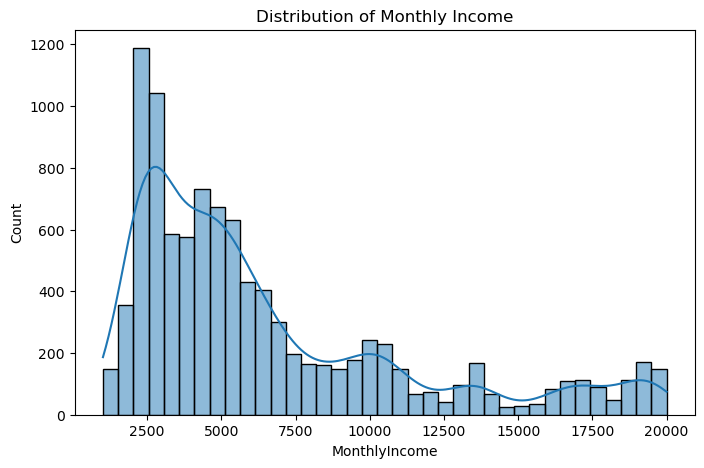

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(hr['MonthlyIncome'],kde=True)
plt.title('Distribution of Monthly Income')
plt.show()


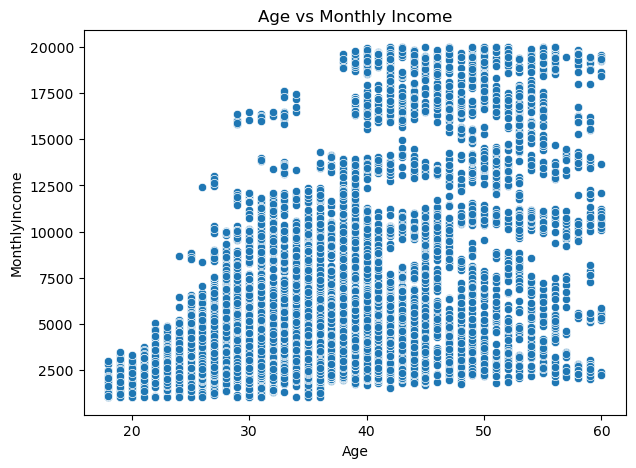

In [18]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Age', y='MonthlyIncome', data=hr)
plt.title('Age vs Monthly Income')
plt.show()

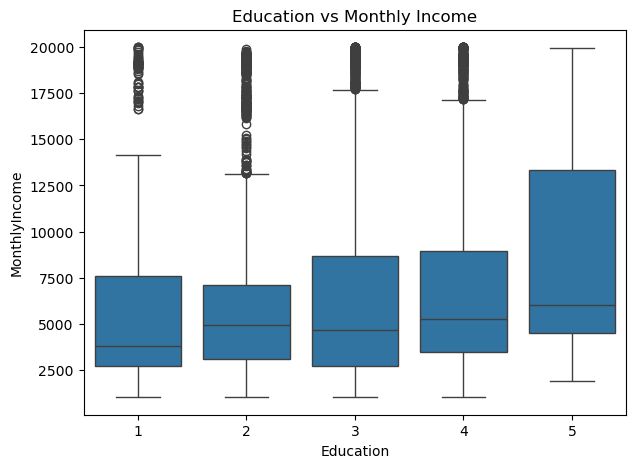

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Education', y='MonthlyIncome', data=hr)
plt.title('Education vs Monthly Income')
plt.show()

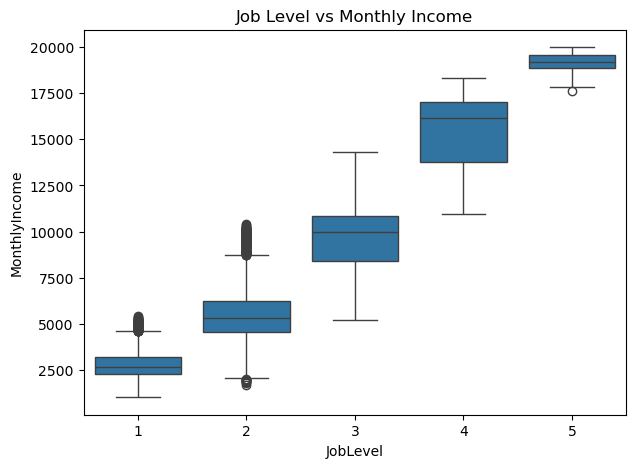

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(x='JobLevel', y='MonthlyIncome', data=hr)
plt.title('Job Level vs Monthly Income')
plt.show()


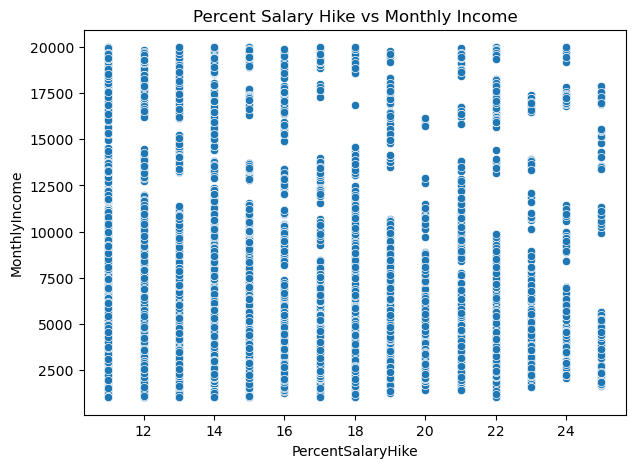

In [23]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='PercentSalaryHike', y='MonthlyIncome', data=hr)
plt.title('Percent Salary Hike vs Monthly Income')
plt.show()


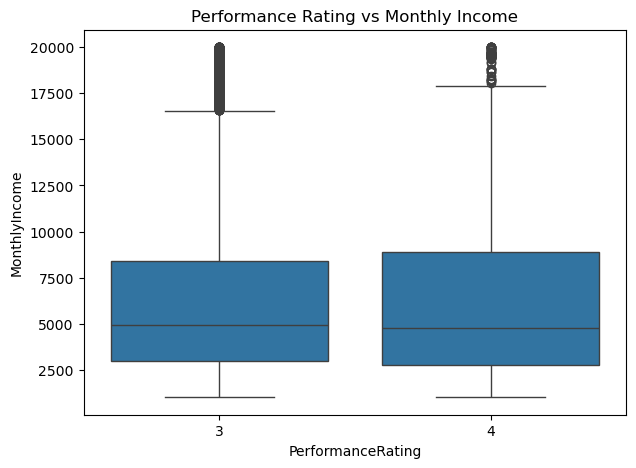

In [25]:
plt.figure(figsize=(7,5))
sns.boxplot(x='PerformanceRating', y='MonthlyIncome', data=hr)
plt.title('Performance Rating vs Monthly Income')
plt.show()


TRAIN MODEL

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((8000, 7), (2000, 7), (8000,), (2000,))

In [30]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

LINEAR AND MULTI REGRESSION

In [31]:
lr = LinearRegression()
lr

LinearRegression()

In [32]:
lr.fit(x_train, y_train)
y_pred_lr_train = lr.predict(x_train)   
y_pred_lr_test  = lr.predict(x_test) 


In [33]:
y_pred_lr_train

array([ 2404.11936157, 17955.32356513,  2201.69254595, ...,
        2334.79977384, 14371.62521272, 10655.045675  ])

In [34]:
y_pred_lr_test  

array([2259.87413322, 5993.04672394, 2704.37254379, ..., 5942.92335695,
       6165.97356991, 6639.06380919])

In [35]:
print("LinearRegression Train R2:", r2_score(y_train, y_pred_lr_train))

LinearRegression Train R2: 0.9076227305208686


In [36]:
print("LinearRegression Test  R2:", r2_score(y_test, y_pred_lr_test))

LinearRegression Test  R2: 0.9024385012257472


In [37]:
print("LinearRegression RMSE:",root_mean_squared_error(y_test, y_pred_lr_test))

LinearRegression RMSE: 1485.7307531681965


In [38]:
print("LinearRegression MSE:", mean_squared_error(y_test, y_pred_lr_test))

LinearRegression MSE: 2207395.8709097365


In [39]:
print("LinearRegression MAE:", mean_absolute_error(y_test, y_pred_lr_test))

LinearRegression MAE: 1138.0551215173355


In [40]:
print("LinearRegression MAPE:", mean_absolute_percentage_error(y_test, y_pred_lr_test))

LinearRegression MAPE: 0.22757463523536103


MULTI-LINEAR REGRESSION

In [51]:
mlr = LinearRegression()
mlr.fit(x_train, y_train)
y_pred_mlr_train = mlr.predict(x_train)   
y_pred_mlr_test = mlr.predict(x_test) 

In [52]:
mlr

LinearRegression()

In [53]:
y_pred_mlr_train 

array([ 2404.11936157, 17955.32356513,  2201.69254595, ...,
        2334.79977384, 14371.62521272, 10655.045675  ])

In [54]:
y_pred_mlr_test

array([2259.87413322, 5993.04672394, 2704.37254379, ..., 5942.92335695,
       6165.97356991, 6639.06380919])

In [55]:
r2_score(y_train, y_pred_mlr_train)

0.9076227305208686

In [56]:
r2_score(y_test, y_pred_mlr_test)

0.9024385012257472

In [57]:
root_mean_squared_error(y_test, y_pred_mlr_test)

1485.7307531681965

In [58]:
mean_squared_error(y_test, y_pred_mlr_test)

2207395.8709097365

In [59]:
mean_absolute_error(y_test, y_pred_mlr_test)

1138.0551215173355

In [60]:
mean_absolute_percentage_error(y_test, y_pred_mlr_test)

0.22757463523536103

POLYNOMIAL REGRESSION

In [61]:
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [62]:
poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

y_pred_poly_test = poly_model.predict(x_test_poly)
y_pred_poly_train = poly_model.predict(x_train_poly)

In [63]:
poly

PolynomialFeatures()

In [64]:
y_pred_poly_test

array([2902.4221045 , 5747.0482963 , 3147.40688727, ..., 5269.74434894,
       5871.68195668, 6074.78310321])

In [65]:
y_pred_poly_train

array([ 2532.4793639 , 19461.76032206,  2584.08973368, ...,
        2876.04599311, 14780.27257852, 10029.19478473])

In [66]:
r2_score(y_train, y_pred_poly_train)

0.9245094982618142

In [67]:
r2_score(y_test, y_pred_poly_test)

0.9208641498627577

In [68]:
root_mean_squared_error(y_test, y_pred_poly_test)

1338.0967543827965

In [69]:
mean_squared_error(y_test, y_pred_poly_test)

1790502.924089774

In [70]:
mean_absolute_error(y_test, y_pred_poly_test)

992.5689197097096

In [71]:
mean_absolute_percentage_error(y_test, y_pred_poly_test)

0.19894335359269538

RIDGE

In [72]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train_scaled, y_train)

y_pred_ridge = ridge.predict(x_test_scaled)

In [73]:
ridge

Ridge()

In [74]:
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2:", r2_score(y_test, y_pred_ridge))
print("MAPE:",mean_absolute_percentage_error(y_test, y_pred_ridge))
print("RMAR:",root_mean_squared_error(y_test, y_pred_ridge))

MAE: 1138.0041788901892
MSE: 2207397.8585106544
R2: 0.9024384133786478
MAPE: 0.22754974446490275
RMAR: 1485.731422064787


LASSO

In [75]:
lasso = Lasso(alpha=0.01)
lasso.fit(x_train_scaled, y_train)

y_pred_lasso = lasso.predict(x_test_scaled)

In [76]:
lasso

Lasso(alpha=0.01)

In [77]:
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2:", r2_score(y_test, y_pred_lasso))
print("MAPE:",mean_absolute_percentage_error(y_test, y_pred_lasso))
print("RMAR:",root_mean_squared_error(y_test, y_pred_lasso))

MAE: 1138.0558583094883
MSE: 2207400.0973197706
R2: 0.9024383144287604
MAPE: 0.22757394859707344
RMAR: 1485.7321755012815


In [78]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Multiple Linear Regression',
        'Polynomial Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr_test),
        mean_absolute_error(y_test, y_pred_mlr_test),
        mean_absolute_error(y_test, y_pred_poly_test),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr_test),
        mean_squared_error(y_test, y_pred_mlr_test),
        mean_squared_error(y_test, y_pred_poly_test),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],
    'R2_Score': [
        r2_score(y_test, y_pred_lr_test),
        r2_score(y_test, y_pred_mlr_test),
        r2_score(y_test, y_pred_poly_test),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

print(results)


                        Model          MAE           MSE  R2_Score
0           Linear Regression  1138.055122  2.207396e+06  0.902439
1  Multiple Linear Regression  1138.055122  2.207396e+06  0.902439
2       Polynomial Regression   992.568920  1.790503e+06  0.920864
3            Ridge Regression  1138.004179  2.207398e+06  0.902438
4            Lasso Regression  1138.055858  2.207400e+06  0.902438


In [79]:
results.sort_values(by='R2_Score', ascending=False)

,Model,MAE,MSE,R2_Score
2,Polynomial Regression,992.568920,1.790503e+06,0.920864
0,Linear Regression,1138.055122,2.207396e+06,0.902439
1,Multiple Linear Regression,1138.055122,2.207396e+06,0.902439
3,Ridge Regression,1138.004179,2.207398e+06,0.902438
4,Lasso Regression,1138.055858,2.207400e+06,0.902438


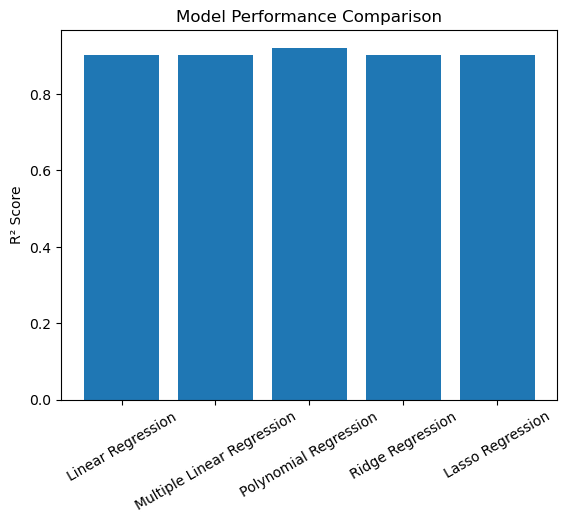

In [80]:
import matplotlib.pyplot as plt

plt.bar(results['Model'], results['R2_Score'])
plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.show()

In [81]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))


Decision Tree R2: 0.985283984754462
